<a href="https://colab.research.google.com/github/FIRDAUSZAINALSG2K/step-trend/blob/plot-the-graph/step_trend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import matplotlib.pyplot as plt


In [31]:

# Update the path to your file in Google Drive
file_path = "/content/step  - Sheet1.csv"
df = pd.read_csv(file_path)
df.head()


,date,goal step,step taken
0,Sun 12/Jul/2026,1200,11507.0
1,Mon 13/Jul/2026,1200,15616.0
2,Tue 14/Jul/2026,1200,12969.0
3,Wed 15/Jul/2026,1200,5333.0
4,Thu 16/Jul/2026,1200,5243.0


Current columns: ['date', 'goal step', 'step taken']


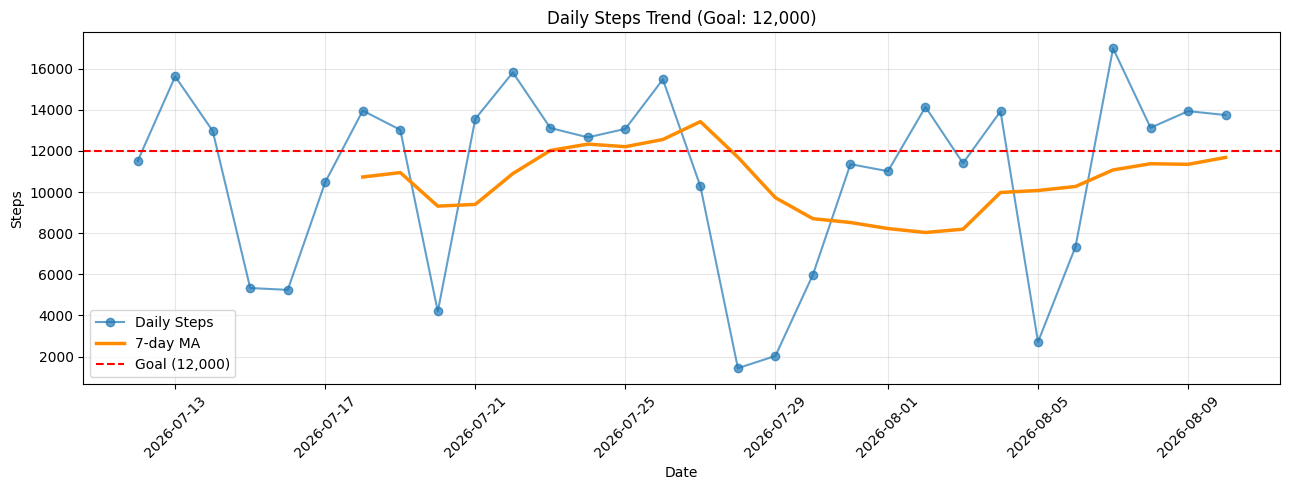

In [32]:

# Clean column names
df.columns = df.columns.str.strip()
print("Current columns:", df.columns.tolist())   # just to check

# Rename properly
df = df.rename(columns={
    'date': 'date',
    'goal step': 'goal',
    'step taken': 'steps'
})

# Keep only useful rows
df = df.dropna(subset=['date', 'steps']).copy()

# Convert date safely
df['date'] = df['date'].astype(str).str.strip()
df['date'] = pd.to_datetime(df['date'], format='%a %d/%b/%Y')
df['steps'] = df['steps'].astype(int)

# 7-day moving average
df['ma7'] = df['steps'].rolling(window=7).mean()

# === PLOT ===
plt.figure(figsize=(13, 5))
plt.plot(df['date'], df['steps'], marker='o', alpha=0.7, label='Daily Steps')
plt.plot(df['date'], df['ma7'], color='darkorange', linewidth=2.5, label='7-day MA')
plt.axhline(y=12000, color='red', linestyle='--', label='Goal (12,000)')

plt.title('Daily Steps Trend (Goal: 12,000)')
plt.xlabel('Date')
plt.ylabel('Steps')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()